In [2]:
import random
import numpy as np
import torch
import os

def set_seed(seed=42):
    # Python random
    random.seed(seed)

    # Numpy
    np.random.seed(seed)

    # PyTorch CPU
    torch.manual_seed(seed)

    # PyTorch GPU
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Ensures deterministic behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # For hash-based ops
    os.environ["PYTHONHASHSEED"] = str(seed)

# Set seed
set_seed(42)


In [11]:

import pandas as pd
import faiss

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# HuggingFace
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer
)

# PyTorch utilities
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn

# Device setup (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load tokenizer once (used for all datasets)
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

In [4]:
!pip install transformers datasets faiss-cpu sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 77.5 MB/s eta 0:00:00:00:0100:01


In [6]:

# Tokenization Function
# Converts raw text to input_ids and attention_mask

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )


# Extract CLS embeddings from RoBERTa encoder

def extract_embeddings(model, dataset):
    model.eval()
    loader = DataLoader(dataset, batch_size=32)
    embeddings = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        with torch.no_grad():
            outputs = model.roberta(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        # CLS token representation
        cls = outputs.last_hidden_state[:, 0, :]
        embeddings.append(cls.cpu())

    return torch.cat(embeddings).numpy()
 


# ISOT (Source dataset)


In [12]:


# Proper ISOT split (Train / Validation / Test) + Pretraining + Evaluation
# ============================================================

import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from datasets import Dataset
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer
)

# ============================================================
# 1. Load ISOT Dataset
# ============================================================

ISOT_PATH = "/kaggle/input/datasets/shreyankchoudhary/isot-data/"

fake_df = pd.read_csv(ISOT_PATH + "Fake.csv")
real_df = pd.read_csv(ISOT_PATH + "True.csv")

fake_df["label"] = 0
real_df["label"] = 1

isot_df = pd.concat([fake_df, real_df], ignore_index=True)

# Keep only required columns and clean
isot_df = isot_df[["text", "label"]]
isot_df.dropna(inplace=True)
isot_df.drop_duplicates(inplace=True)

print("Total ISOT samples:", len(isot_df))

# ============================================================
# 2. Proper Train / Validation / Test split
# ============================================================

# First split → Train (80%) and Temp (20%)
isot_train_df, isot_temp_df = train_test_split(
    isot_df,
    test_size=0.2,
    stratify=isot_df["label"],
    random_state=42
)
# Split Temp → Validation (10%) and Test (10%)
isot_validation_df, isot_test_df = train_test_split(
    isot_temp_df,
    test_size=0.5,
    stratify=isot_temp_df["label"],
    random_state=42
)

print("\nSplit sizes:")
print("Train:", len(isot_train_df))
print("Validation:", len(isot_validation_df))
print("Test:", len(isot_test_df))

# ============================================================
# 3. Load tokenizer
# ============================================================

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )
# ============================================================
# 4. Convert to HuggingFace Dataset
# ============================================================

isot_train_dataset = Dataset.from_pandas(isot_train_df)
isot_validation_dataset = Dataset.from_pandas(isot_validation_df)
isot_test_dataset = Dataset.from_pandas(isot_test_df)

# Tokenize
isot_train_dataset = isot_train_dataset.map(tokenize_function, batched=True)
isot_validation_dataset = isot_validation_dataset.map(tokenize_function, batched=True)
isot_test_dataset = isot_test_dataset.map(tokenize_function, batched=True)

# Set format
isot_train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

isot_validation_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

isot_test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)
# ============================================================
# 5. Load RoBERTa model
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

isot_model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
).to(device)

# ============================================================
# 6. Metrics function
# ============================================================

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc
    }
    # 7. Training Arguments
# ============================================================

isot_training_args = TrainingArguments(

    output_dir="./isot_proper_pretraining",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True,
    report_to="none"
)
# 8. Trainer
# ============================================================

isot_trainer = Trainer(

    model=isot_model,
    args=isot_training_args,

    train_dataset=isot_train_dataset,

    eval_dataset=isot_validation_dataset,

    compute_metrics=compute_metrics
)

# ============================================================
# 9. Train model
# ============================================================

print("\nStarting ISOT pretraining...")

isot_trainer.train()

# ============================================================
# 10. Evaluate on Validation set
# ============================================================

print("\nValidation Results:")
test_predictions = isot_trainer.predict(
    isot_test_dataset
)

test_preds = np.argmax(test_predictions.predictions, axis=1)

test_accuracy = accuracy_score(
    test_predictions.label_ids,
    test_preds
)

print("\nISOT Test Accuracy:", test_accuracy)
print("\nClassification Report:")
print(
    classification_report(
        test_predictions.label_ids,
        test_preds,
        target_names=["Fake", "Real"]
    )
)

# ============================================================
# 12. Save final model checkpoint
# ============================================================

isot_trainer.save_model("./isot_proper_pretrained_checkpoint")

print("\nISOT model saved successfully.")


Total ISOT samples: 38647

Split sizes:
Train: 30917
Validation: 3865
Test: 3865


Map:   0%|          | 0/30917 [00:00<?, ? examples/s]

Map:   0%|          | 0/3865 [00:00<?, ? examples/s]

Map:   0%|          | 0/3865 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Starting ISOT pretraining...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.001300,0.028991,0.996636
2,0.004000,0.005472,0.999224
3,0.000700,0.003065,0.999741



Validation Results:



ISOT Test Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      1746
        Real       1.00      1.00      1.00      2119

    accuracy                           1.00      3865
   macro avg       1.00      1.00      1.00      3865
weighted avg       1.00      1.00      1.00      3865


ISOT model saved successfully.


In [13]:
import os
print(os.listdir("./isot_proper_pretraining"))

['checkpoint-1933', 'checkpoint-5799', 'checkpoint-3866']


In [14]:
# Load COVID dataset
covid_train = pd.read_csv("/kaggle/input/datasets/shreyankchoudhary/covid19-data/Copy of Constraint_English_Train - Sheet1.csv")
covid_test = pd.read_csv("/kaggle/input/datasets/shreyankchoudhary/covid19-data/Constraint_English_Val - Sheet1.csv")

covid_train["label"] = covid_train["label"].map({"fake":0,"real":1})
covid_test["label"] = covid_test["label"].map({"fake":0,"real":1})

# Convert to HF dataset
covid_train_dataset = Dataset.from_dict({
    "text": covid_train["tweet"].values,
    "label": covid_train["label"].values
}).map(tokenize_batch, batched=True)

covid_test_dataset = Dataset.from_dict({
    "text": covid_test["tweet"].values,
    "label": covid_test["label"].values
}).map(tokenize_batch, batched=True)

covid_train_dataset.set_format("torch", columns=["input_ids","attention_mask","label"])
covid_test_dataset.set_format("torch", columns=["input_ids","attention_mask","label"])


Map:   0%|          | 0/6420 [00:00<?, ? examples/s]

Map:   0%|          | 0/2140 [00:00<?, ? examples/s]

## Cross-Validating ISOT-Initialized RoBERTa on COVID

In [15]:

# Load ISOT trained checkpoint
covid_model = RobertaForSequenceClassification.from_pretrained(
    "./isot_proper_pretraining/checkpoint-5799"  
).to(device)

# Freeze all layers
for p in covid_model.roberta.parameters():
    p.requires_grad = False

# Unfreeze last 3 transformer layers
for layer in covid_model.roberta.encoder.layer[-3:]:
    for p in layer.parameters():
        p.requires_grad = True

# Unfreeze classifier
for p in covid_model.classifier.parameters():
    p.requires_grad = True

covid_args = TrainingArguments(
    output_dir="./covid_adapt",
    num_train_epochs=5,
    learning_rate=1e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    max_grad_norm=1.0,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="no",
    seed=42,
    fp16=True,
    report_to="none"
)



covid_trainer = Trainer(
    model=covid_model,
    args=covid_args,
    train_dataset=covid_train_dataset,
    eval_dataset=covid_test_dataset,
)

covid_trainer.train()

covid_preds = covid_trainer.predict(covid_test_dataset)

isot_covid_acc = accuracy_score(
    covid_preds.label_ids,
    covid_preds.predictions.argmax(axis=1)
)

print("ISOT-Initialized RoBERTa COVID Accuracy:", isot_covid_acc)

Epoch,Training Loss,Validation Loss
1,No log,0.668655
2,1.380500,0.593680
3,0.639900,0.799314
4,0.601800,0.868917
5,0.573700,0.816639


ISOT-Initialized RoBERTa COVID Accuracy: 0.6350467289719626



ISOT-Initialized RoBERTa COVID Results
--------------------------------------
Accuracy: 0.6350

Classification Report:

              precision    recall  f1-score   support

        Fake       0.93      0.25      0.40      1020
        Real       0.59      0.98      0.74      1120

    accuracy                           0.64      2140
   macro avg       0.76      0.62      0.57      2140
weighted avg       0.75      0.64      0.58      2140



<Figure size 600x500 with 0 Axes>

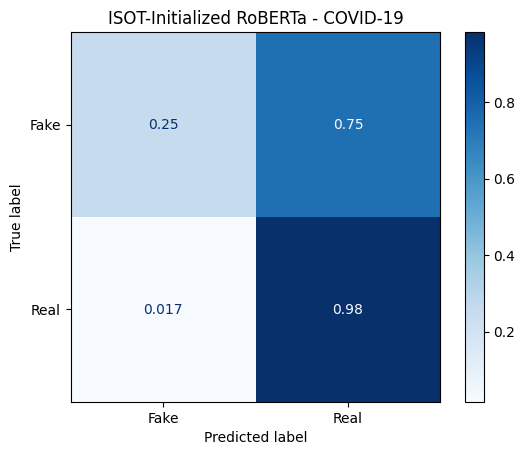

In [16]:
# ===============================
# ISOT-INITIALIZED ROBERTA (COVID)
# Classification Report + Confusion Matrix
# ===============================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

# ---- Extract labels from YOUR predictions ----
y_true = covid_preds.label_ids
y_pred = np.argmax(covid_preds.predictions, axis=1)

# ---- Accuracy ----
acc = accuracy_score(y_true, y_pred)

print("\nISOT-Initialized RoBERTa COVID Results")
print("--------------------------------------")
print(f"Accuracy: {acc:.4f}")

# ---- Classification Report ----
print("\nClassification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Fake", "Real"]
    )
)

# ---- Confusion Matrix ----
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["Fake", "Real"],
    cmap="Blues",
    normalize="true"   # percentage view (paper-friendly)
)

plt.title("ISOT-Initialized RoBERTa - COVID-19")

plt.savefig(
    "isot_initialized_covid_confusion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
#COVID test dataset for final unbiased evaluation

covid_val = pd.read_csv("/kaggle/input/datasets/shreyankchoudhary/val-covid/english_test_with_labels - Sheet1.csv")

# Convert labels to numeric
covid_val["label"] = covid_val["label"].map({
    "fake": 0,
    "real": 1
})


# Convert COVID validation pandas DataFrame → HuggingFace Dataset

from datasets import Dataset
covid_val_dataset = Dataset.from_dict({

    "text": covid_val["tweet"].values,

    "labels": covid_val["label"].values

})


# Tokenize COVID validation dataset using RoBERTa tokenizer

covid_val_dataset = covid_val_dataset.map(
    tokenize_batch,
    batched=True
)

# Convert COVID validation dataset into PyTorch tensor format
covid_val_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)


Map:   0%|          | 0/2140 [00:00<?, ? examples/s]

In [18]:

from sklearn.metrics import accuracy_score
import numpy as np

# Get predictions
covid_val_preds = covid_trainer.predict(covid_val_dataset)

# Convert logits → predicted labels
predicted_labels = np.argmax(covid_val_preds.predictions, axis=1)

# True labels
true_labels = covid_val_preds.label_ids

# Accuracy
test_accuracy = accuracy_score(true_labels, predicted_labels)

print("COVID Test Accuracy:", test_accuracy)

COVID Test Accuracy: 0.6359813084112149


# gossipcop on isot initialized roberta

In [19]:
# ============================================================
# CELL FUNCTION:
# GossipCop Train / Validation / Test split + ISOT adaptation
# ============================================================

import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from datasets import Dataset
from transformers import RobertaForSequenceClassification, TrainingArguments, Trainer


# ============================================================
# 1. Load and clean GossipCop dataset
# ============================================================

gossip_df = pd.read_csv("/kaggle/input/datasets/shreyankchoudhary/gossip-data/gossipcop.csv")

# Convert labels
gossip_df["label"] = gossip_df["label"].map({"fake": 0, "real": 1})

# Remove missing values
gossip_df = gossip_df.dropna(subset=["text", "label"])

print("Total samples:", len(gossip_df))


# ============================================================
# 2. Proper Train / Validation / Test split
# ============================================================

# Train 80%, Temp 20%
gossip_train_df, gossip_temp_df = train_test_split(
    gossip_df,
    test_size=0.2,
    stratify=gossip_df["label"],
    random_state=42
)

# Validation 10%, Test 10%
gossip_validation_df, gossip_test_df = train_test_split(
    gossip_temp_df,
    test_size=0.5,
    stratify=gossip_temp_df["label"],
    random_state=42
)

print("\nSplit sizes:")
print("Train:", len(gossip_train_df))
print("Validation:", len(gossip_validation_df))
print("Test:", len(gossip_test_df))


# ============================================================
# 3. Convert to HuggingFace Dataset
# ============================================================

gossip_train_dataset = Dataset.from_dict({
    "text": gossip_train_df["text"].values,
    "label": gossip_train_df["label"].values
}).map(tokenize_batch, batched=True)

gossip_validation_dataset = Dataset.from_dict({
    "text": gossip_validation_df["text"].values,
    "label": gossip_validation_df["label"].values
}).map(tokenize_batch, batched=True)

gossip_test_dataset = Dataset.from_dict({
    "text": gossip_test_df["text"].values,
    "label": gossip_test_df["label"].values
}).map(tokenize_batch, batched=True)


# Set torch format
gossip_train_dataset.set_format(
    "torch",
    columns=["input_ids", "attention_mask", "label"]
)

gossip_validation_dataset.set_format(
    "torch",
    columns=["input_ids", "attention_mask", "label"]
)

gossip_test_dataset.set_format(
    "torch",
    columns=["input_ids", "attention_mask", "label"]
)


# ============================================================
# 4. Load ISOT-initialized RoBERTa
# ============================================================

gossip_model = RobertaForSequenceClassification.from_pretrained(
    "./isot_proper_pretraining/checkpoint-5799"
).to(device)


# ============================================================
# 5. Freeze / Unfreeze layers
# ============================================================

# Freeze all encoder layers
for param in gossip_model.roberta.parameters():
    param.requires_grad = False


# Unfreeze last 3 layers
for layer in gossip_model.roberta.encoder.layer[-3:]:
    for param in layer.parameters():
        param.requires_grad = True


# Always unfreeze classifier
for param in gossip_model.classifier.parameters():
    param.requires_grad = True


# ============================================================
# 6. Training Arguments
# ============================================================

gossip_args = TrainingArguments(

    output_dir="./gossip_adapt",

    num_train_epochs=5,

    learning_rate=1e-5,

    warmup_ratio=0.1,

    weight_decay=0.01,

    max_grad_norm=1.0,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    eval_strategy="epoch",

    save_strategy="no",

    seed=42,

    fp16=True,

    report_to="none"
)


# ============================================================
# 7. Trainer
# ============================================================

gossip_trainer = Trainer(

    model=gossip_model,

    args=gossip_args,

    train_dataset=gossip_train_dataset,

    eval_dataset=gossip_validation_dataset
)


# ============================================================
# 8. Train model
# ============================================================

print("\nTraining GossipCop adaptation...")

gossip_trainer.train()


# ============================================================
# 9. Validation performance
# ============================================================

validation_results = gossip_trainer.evaluate(
    eval_dataset=gossip_validation_dataset
)

print("\nValidation Results:", validation_results)


# ============================================================
# 10. Final unbiased Test evaluation
# ============================================================

gossip_test_predictions = gossip_trainer.predict(
    gossip_test_dataset
)

gossip_test_preds = np.argmax(
    gossip_test_predictions.predictions,
    axis=1
)

gossip_test_acc = accuracy_score(
    gossip_test_predictions.label_ids,
    gossip_test_preds
)

print("\nFinal GossipCop Test Accuracy:", gossip_test_acc)

print("\nClassification Report:")

print(
    classification_report(
        gossip_test_predictions.label_ids,
        gossip_test_preds,
        target_names=["Fake", "Real"]
    )
)

Total samples: 20007

Split sizes:
Train: 16005
Validation: 2001
Test: 2001


Map:   0%|          | 0/16005 [00:00<?, ? examples/s]

Map:   0%|          | 0/2001 [00:00<?, ? examples/s]

Map:   0%|          | 0/2001 [00:00<?, ? examples/s]


Training GossipCop adaptation...


Epoch,Training Loss,Validation Loss
1,0.552900,0.551307
2,0.554100,0.550345
3,0.553100,0.545234
4,0.539100,0.542622
5,0.545600,0.539184



Validation Results: {'eval_loss': 0.539184033870697, 'eval_runtime': 13.8447, 'eval_samples_per_second': 144.531, 'eval_steps_per_second': 9.101, 'epoch': 5.0}

Final GossipCop Test Accuracy: 0.7606196901549226

Classification Report:
              precision    recall  f1-score   support

        Fake       0.00      0.00      0.00       479
        Real       0.76      1.00      0.86      1522

    accuracy                           0.76      2001
   macro avg       0.38      0.50      0.43      2001
weighted avg       0.58      0.76      0.66      2001



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Covid dataset trained on vanilla roberta-base

In [29]:
from transformers import RobertaForSequenceClassification, TrainingArguments, Trainer

vanilla_covid_model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
).to(device)


vanilla_covid_args = TrainingArguments(
    output_dir="./vanilla_covid",
    num_train_epochs=3,
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="no",
    seed=42,
    fp16=True,
    report_to="none"
)

vanilla_covid_trainer = Trainer(
    model=vanilla_covid_model,
    args=vanilla_covid_args,
    train_dataset=covid_train_dataset,
    eval_dataset=covid_test_dataset
)

vanilla_covid_trainer.train()

from sklearn.metrics import accuracy_score

covid_preds = vanilla_covid_trainer.predict(covid_test_dataset)

vanilla_covid_acc = accuracy_score(
    covid_preds.label_ids,
    covid_preds.predictions.argmax(axis=1)
)

print("Vanilla RoBERTa COVID Accuracy:", vanilla_covid_acc)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,No log,0.163092
2,0.221200,0.145067
3,0.082200,0.148145


Vanilla RoBERTa COVID Accuracy: 0.9738317757009346



Vanilla RoBERTa COVID Results
--------------------------------
Accuracy: 0.9696

Classification Report:

              precision    recall  f1-score   support

        Fake       0.98      0.95      0.97      1020
        Real       0.96      0.99      0.97      1120

    accuracy                           0.97      2140
   macro avg       0.97      0.97      0.97      2140
weighted avg       0.97      0.97      0.97      2140



<Figure size 600x500 with 0 Axes>

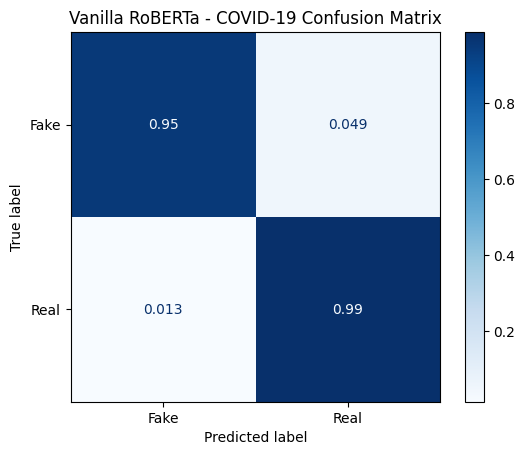

In [21]:
# ============================================================
# Vanilla RoBERTa - COVID Dataset
# Classification Report + Confusion Matrix
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

# ---- Extract predictions ----
y_true = covid_preds.label_ids
y_pred = np.argmax(covid_preds.predictions, axis=1)

# ---- Accuracy ----
accuracy = accuracy_score(y_true, y_pred)

print("\nVanilla RoBERTa COVID Results")
print("--------------------------------")
print(f"Accuracy: {accuracy:.4f}")

# ---- Classification Report ----
print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Fake", "Real"]
    )
)

# ---- Confusion Matrix ----
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["Fake", "Real"],
    cmap="Blues",
    normalize="true"   # percentage form (better for paper)
)

plt.title("Vanilla RoBERTa - COVID-19 Confusion Matrix")

# ---- Save figure for paper ----
plt.savefig(
    "vanilla_covid_confusion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# gossipcop dataset trained on vanilla Robert-base

In [22]:
#Initialize Vanilla Model
vanilla_gossip_model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
).to(device)
#Training Arguments
vanilla_gossip_args = TrainingArguments(
    output_dir="./vanilla_gossip",
    num_train_epochs=3,
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="no",
    seed=42,
    fp16=True,
    report_to="none"
)

vanilla_gossip_trainer = Trainer(
    model=vanilla_gossip_model,
    args=vanilla_gossip_args,
    train_dataset=gossip_train_dataset,
    eval_dataset=gossip_test_dataset
)
vanilla_gossip_trainer.train()
# Evaluate
gossip_preds = vanilla_gossip_trainer.predict(gossip_test_dataset)

vanilla_gossip_acc = accuracy_score(
    gossip_preds.label_ids,
    gossip_preds.predictions.argmax(axis=1)
)

print("Vanilla RoBERTa Gossip Accuracy:", vanilla_gossip_acc)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.352500,0.347175
2,0.303700,0.356793
3,0.268200,0.358863


Vanilla RoBERTa Gossip Accuracy: 0.8630684657671165



Vanilla RoBERTa GossipCop Results
-----------------------------------
Accuracy: 0.8631

Classification Report:

              precision    recall  f1-score   support

        Fake       0.75      0.63      0.69       479
        Real       0.89      0.93      0.91      1522

    accuracy                           0.86      2001
   macro avg       0.82      0.78      0.80      2001
weighted avg       0.86      0.86      0.86      2001



<Figure size 600x500 with 0 Axes>

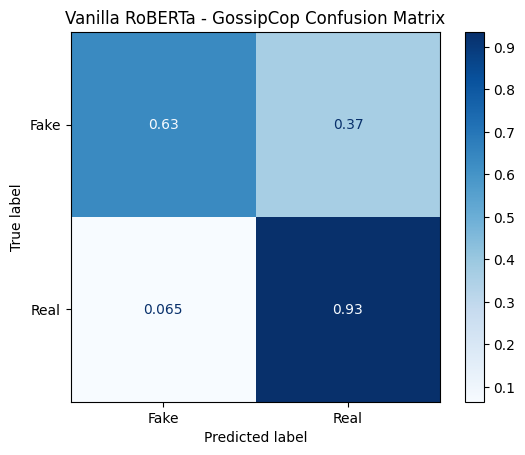

In [23]:
# ============================================================
# Vanilla RoBERTa - GossipCop Dataset
# Classification Report + Confusion Matrix
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

# ---- Extract predictions ----
y_true = gossip_preds.label_ids
y_pred = np.argmax(gossip_preds.predictions, axis=1)

# ---- Accuracy ----
accuracy = accuracy_score(y_true, y_pred)

print("\nVanilla RoBERTa GossipCop Results")
print("-----------------------------------")
print(f"Accuracy: {accuracy:.4f}")

# ---- Classification Report ----
print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Fake", "Real"]
    )
)

# ---- Confusion Matrix ----
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["Fake", "Real"],
    cmap="Blues",
    normalize="true"   # normalized for publication
)

plt.title("Vanilla RoBERTa - GossipCop Confusion Matrix")

# ---- Save figure for paper ----
plt.savefig(
    "vanilla_gossip_confusion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# welfake vanilla

In [24]:
import pandas as pd

welfake = pd.read_csv(
    "/kaggle/input/datasets/shreyankchoudhary/welfake/WELFake_Dataset.csv"
)

print("Dataset shape:", welfake.shape)
print(welfake.columns)
print(welfake.head())                                                                      

# Clean WELFake dataset, remove invalid rows

# Keep only text and label columns
welfake = welfake[["text", "label"]]


# Drop rows where text is missing
welfake = welfake.dropna(subset=["text"])

# Drop rows where label is missing
welfake = welfake.dropna(subset=["label"])

# Convert label to integer
welfake["label"] = welfake["label"].astype(int)

# Reset index (recommended after dropping rows)
welfake = welfake.reset_index(drop=True)

# Rename text column to content (for compatibility with your pipeline)
welfake = welfake.rename(columns={"text": "content"})

# Check label distribution
print("Label distribution:")
print(welfake["label"].value_counts())

# Check total rows
print("\nTotal rows after cleaning:", len(welfake))

Dataset shape: (72134, 4)
Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')
   Unnamed: 0                                              title  \
0           0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1           1                                                NaN   
2           2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3           3  Bobby Jindal, raised Hindu, uses story of Chri...   
4           4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  
3  A dozen politically active pastors came here f...      0  
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1  
Label distribution:
label
1    37067
0    35028
Name: count, dtype: int64

Total rows after cleaning: 72095


In [25]:
welfake_train, welfake_temp = train_test_split(

    welfake,
    test_size=0.3,
    stratify=welfake["label"],
    random_state=42
)

# Second split: test (15%) and validation (15%)
welfake_test, welfake_validation = train_test_split(

    welfake_temp,
    test_size=0.5,
    stratify=welfake_temp["label"],
    random_state=42
)

print("Train:", len(welfake_train))
print("Test:", len(welfake_test))
print("Validation:", len(welfake_validation))

Train: 50466
Test: 10814
Validation: 10815


In [26]:

welfake_train_dataset = Dataset.from_dict({

    "text": welfake_train["content"].values,
    "labels": welfake_train["label"].values
})

welfake_test_dataset = Dataset.from_dict({

    "text": welfake_test["content"].values,
    "labels": welfake_test["label"].values
})

welfake_validation_dataset = Dataset.from_dict({

    "text": welfake_validation["content"].values,
    "labels": welfake_validation["label"].values
})

In [27]:
# Tokenize WELFake datasets

welfake_train_dataset = welfake_train_dataset.map(
    tokenize_batch,
    batched=True
)

welfake_test_dataset = welfake_test_dataset.map(
    tokenize_batch,
    batched=True
)

welfake_validation_dataset = welfake_validation_dataset.map(
    tokenize_batch,
    batched=True
)
# Convert to PyTorch format

welfake_train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

welfake_test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

welfake_validation_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

Map:   0%|          | 0/50466 [00:00<?, ? examples/s]

Map:   0%|          | 0/10814 [00:00<?, ? examples/s]

Map:   0%|          | 0/10815 [00:00<?, ? examples/s]

In [30]:
# Train Vanilla RoBERTa on WELFake and calculate accuracy


import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report

from transformers import (
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer
)

# ============================================================
# 1. Load Vanilla RoBERTa
# ============================================================

welfake_vanilla_model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
).to(device)


# ============================================================
# 2. Training Arguments
# ============================================================

welfake_vanilla_args = TrainingArguments(

    output_dir="./welfake_vanilla_results",

    num_train_epochs=3,

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    eval_strategy="epoch",

    save_strategy="no",

    fp16=True,

    report_to="none"
)


# ============================================================
# 3. Trainer
# ============================================================

welfake_vanilla_trainer = Trainer(

    model=welfake_vanilla_model,

    args=welfake_vanilla_args,

    train_dataset=welfake_train_dataset,

    eval_dataset=welfake_validation_dataset
)


# ============================================================
# 4. Train model
# ============================================================

print("\nTraining Vanilla RoBERTa on WELFake...")

welfake_vanilla_trainer.train()


# ============================================================
# 5. Evaluate on Test Dataset (Final Accuracy)
# ============================================================

welfake_test_predictions = welfake_vanilla_trainer.predict(
    welfake_test_dataset
)

welfake_test_preds = np.argmax(
    welfake_test_predictions.predictions,
    axis=1
)

welfake_test_accuracy = accuracy_score(
    welfake_test_predictions.label_ids,
    welfake_test_preds
)

print("\nVanilla RoBERTa WELFake Test Accuracy:", welfake_test_accuracy)


# ============================================================
# 6. Classification Report
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        welfake_test_predictions.label_ids,
        welfake_test_preds,
        target_names=["Fake", "Real"]
    )
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Training Vanilla RoBERTa on WELFake...


Epoch,Training Loss,Validation Loss
1,0.016800,0.007079
2,0.004300,0.003593
3,0.003600,0.004094



Vanilla RoBERTa WELFake Test Accuracy: 0.9990752727945256

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      5254
        Real       1.00      1.00      1.00      5560

    accuracy                           1.00     10814
   macro avg       1.00      1.00      1.00     10814
weighted avg       1.00      1.00      1.00     10814




Vanilla RoBERTa WELFake Results
--------------------------------
Accuracy: 0.9991

Classification Report:

              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      5254
        Real       1.00      1.00      1.00      5560

    accuracy                           1.00     10814
   macro avg       1.00      1.00      1.00     10814
weighted avg       1.00      1.00      1.00     10814



<Figure size 600x500 with 0 Axes>

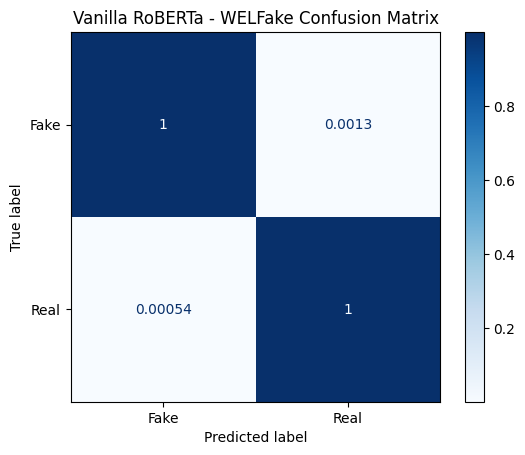

In [31]:
# ============================================================
# Vanilla RoBERTa - WELFake Dataset
# Classification Matrix + Confusion Matrix
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

# ---- Extract labels ----
y_true = welfake_test_predictions.label_ids
y_pred = np.argmax(
    welfake_test_predictions.predictions,
    axis=1
)

# ---- Accuracy ----
accuracy = accuracy_score(y_true, y_pred)

print("\nVanilla RoBERTa WELFake Results")
print("--------------------------------")
print(f"Accuracy: {accuracy:.4f}")

# ---- Classification Report ----
print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Fake", "Real"]
    )
)

# ---- Confusion Matrix ----
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["Fake", "Real"],
    cmap="Blues",
    normalize="true"   # normalized (IEEE preferred)
)

plt.title("Vanilla RoBERTa - WELFake Confusion Matrix")

# ---- Save high-quality figure ----
plt.savefig(
    "vanilla_welfake_confusion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Isot initialized welfake


Training ISOT-Initialized RoBERTa on WELFake...


Epoch,Training Loss,Validation Loss
1,0.186800,0.392180
2,0.150700,0.106434
3,0.127700,0.177741
4,0.116300,0.135923
5,0.102800,0.141869



ISOT-Initialized RoBERTa WELFake Results
------------------------------------------
Accuracy: 0.9511

Classification Report:

              precision    recall  f1-score   support

        Fake       0.92      0.99      0.95      5254
        Real       0.99      0.92      0.95      5560

    accuracy                           0.95     10814
   macro avg       0.95      0.95      0.95     10814
weighted avg       0.95      0.95      0.95     10814



<Figure size 600x500 with 0 Axes>

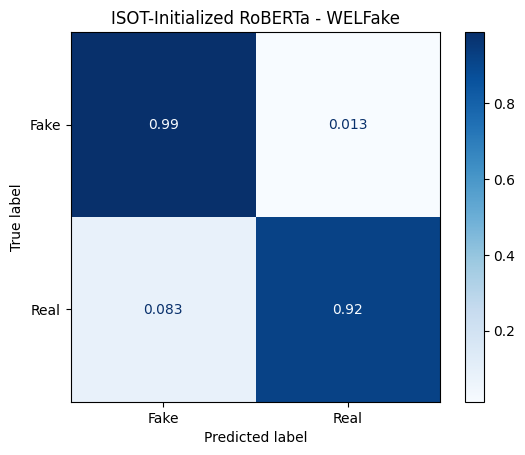

In [32]:
# ============================================================
# ISOT-Initialized RoBERTa → WELFake Dataset
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

from transformers import (
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer
)

# ============================================================
# 1. Load ISOT-pretrained RoBERTa
# ============================================================

welfake_isot_model = RobertaForSequenceClassification.from_pretrained(
    "./isot_proper_pretraining/checkpoint-5799"
).to(device)


# ============================================================
# 2. Freeze All Encoder Layers
# ============================================================

for param in welfake_isot_model.roberta.parameters():
    param.requires_grad = False


# ============================================================
# 3. Unfreeze Last 3 Transformer Layers
# ============================================================

for layer in welfake_isot_model.roberta.encoder.layer[-3:]:
    for param in layer.parameters():
        param.requires_grad = True


# Always train classifier
for param in welfake_isot_model.classifier.parameters():
    param.requires_grad = True


# ============================================================
# 4. Training Arguments
# ============================================================

welfake_isot_args = TrainingArguments(

    output_dir="./welfake_isot_results",

    num_train_epochs=5,

    learning_rate=1e-5,

    warmup_ratio=0.1,
    weight_decay=0.01,
    max_grad_norm=1.0,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    eval_strategy="epoch",
    save_strategy="no",

    seed=42,

    fp16=True,
    report_to="none"
)


# ============================================================
# 5. Trainer
# ============================================================

welfake_isot_trainer = Trainer(

    model=welfake_isot_model,

    args=welfake_isot_args,

    train_dataset=welfake_train_dataset,
    eval_dataset=welfake_validation_dataset
)


# ============================================================
# 6. Train
# ============================================================

print("\nTraining ISOT-Initialized RoBERTa on WELFake...")

welfake_isot_trainer.train()


# ============================================================
# 7. Test Evaluation
# ============================================================

welfake_isot_predictions = welfake_isot_trainer.predict(
    welfake_test_dataset
)

y_true = welfake_isot_predictions.label_ids
y_pred = np.argmax(
    welfake_isot_predictions.predictions,
    axis=1
)

accuracy = accuracy_score(y_true, y_pred)

print("\nISOT-Initialized RoBERTa WELFake Results")
print("------------------------------------------")
print(f"Accuracy: {accuracy:.4f}")


# ============================================================
# 8. Classification Report
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Fake", "Real"]
    )
)


# ============================================================
# 9. Confusion Matrix
# ============================================================

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["Fake", "Real"],
    cmap="Blues",
    normalize="true"
)

plt.title("ISOT-Initialized RoBERTa - WELFake")

plt.savefig(
    "isot_welfake_confusion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()